In [274]:
"""Tool to plot infer some analysis on TPO"""
from dataclasses import dataclass, field
from os import listdir
import matplotlib.pyplot as plt
from pandas import DataFrame, read_csv, concat
from sklearn.linear_model import LinearRegression
# 
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve

In [275]:
# Global variables
SHOW_PLOTS = False
TEST_OUT = False


@dataclass
class Measurment:
    """Class to represent a measurment"""
    filename: str
    data: DataFrame = field(init=False)
    def __post_init__(self):
        self.data = read_csv(self.filename, sep=';', header=0)
        # drop first column
        self.data = self.data.drop(self.data.columns[0], axis=1)
        #substitute comma with dot
        self.data = self.data.apply(lambda x: x.str.replace(',','.'))
        #convert to float
        self.data = self.data.astype(float)
        self.data.columns = [ 'Displacement', self.filename]
        # round the displacement
        self.data['Displacement'] = self.data['Displacement'].apply(lambda x: round(x, 1))
        


    def clean(self, **kwargs):
        """Remove all rows with NaN"""
        self.data = self.data.astype(float)
        #self.data = self.data[self.data["Displacement"] > 0]
        #self.data = self.data[self.data["Displacement"] < 85]    
        self.data = self.data.dropna()
        self.data = self.data.groupby(by='Displacement').mean()
        self.data = shift(self.data,  **kwargs)

def shift(df, **kwargs):
    """Shift the data to the right"""
    N = df.where(df > 1).first_valid_index()
    index = np.array(df.index)
    index = index + 30 - N
    df.index = index

    return df


    


   




def PlotterSingle(namedir, N, cooling_or_heating, **kwargs):

    measurments = []
    exp = DataFrame()
    for filename in listdir(namedir):
        measurments.append(Measurment(namedir+"/"+filename))
        measurments[-1].clean(**kwargs)
        exp = concat([exp, measurments[-1].data], axis=1)
    # if only nans in a row, drop it
    exp = exp.dropna(how='all')
    # fill with mean nans
    exp = exp.fillna(exp.mean(axis=1))

    if SHOW_PLOTS:
        exp.plot( color = "C0",legend=False, style=".",
                  linewidth=0.4, figsize=(7, 4), alpha=0.1)
    
    mean = exp.mean(axis=1)
    for i in mean : print(i)
    mean.plot(color="black", legend=False, linewidth=1.5, figsize=(10, 5), label = "mean")
    plt.grid()
    std = exp.std(axis=1)
    plt.fill_between(mean.index, mean-std, mean+std, color="C0", alpha=0.5, label = "std")
    plt.xlabel("Displacement [°C]")
    plt.ylabel("Heat flow [mW]")
    plt.title("DSC thermogram oleogel RBX/RSO "+str(N)+"% "+cooling_or_heating)
    plt.tight_layout()

    plt.legend([])
    plt.savefig(namedir+".png", dpi=1000)

    # save the data as a csv file
    exp.to_csv(str(N)+"test.csv", sep=';')

def PlotterMultiple(namedir, displacement,cooling_or_heating,  **kwargs):
    pass




In [276]:
p = 0.9
lam = 10**12
niter = 10
kwargs = {"p": p, "lam": lam, "niter": niter}
cooling_or_heating = "cooling"

SHOW_PLOTS = False

-0.02432
-0.01837
-0.01226
-0.00554
-0.00254
-0.00847
0.0101
-0.018486666666666665
-0.00647
-0.022709999999999998
-0.021986666666666665
-0.0029
-0.012556666666666667
-0.01339
-0.02333666666666667
-0.019600000000000003
-0.01059
-0.014236666666666667
-0.0265
-0.018616666666666667
-0.020993333333333333
-0.008
-0.019986666666666666
-0.01493
-0.029910000000000003
-0.03294666666666667
-0.01457
-0.02266666666666667
-0.01569
-0.01574666666666667
-0.030606666666666667
-0.00481
-0.013786666666666668
-0.01785
-0.022316666666666665
-0.024216666666666664
-0.00117
-0.02119
-0.00129
-0.014043333333333336
-0.0193
-0.00882
-0.01992333333333333
-0.01015
-0.022186666666666664
-0.013626666666666667
-0.01422
-0.027466666666666667
-0.01609
-0.01875
-0.016676666666666666
-0.0109
-0.020896666666666664
-0.01281
-0.01746
-0.015019999999999999
-0.02347
-0.01256
-0.0083
-0.008929999999999999
-0.015133333333333334
0.00035
-0.022816666666666666
0.00795
-0.010916666666666667
-0.010640000000000002
-0.01724
-0.0277633

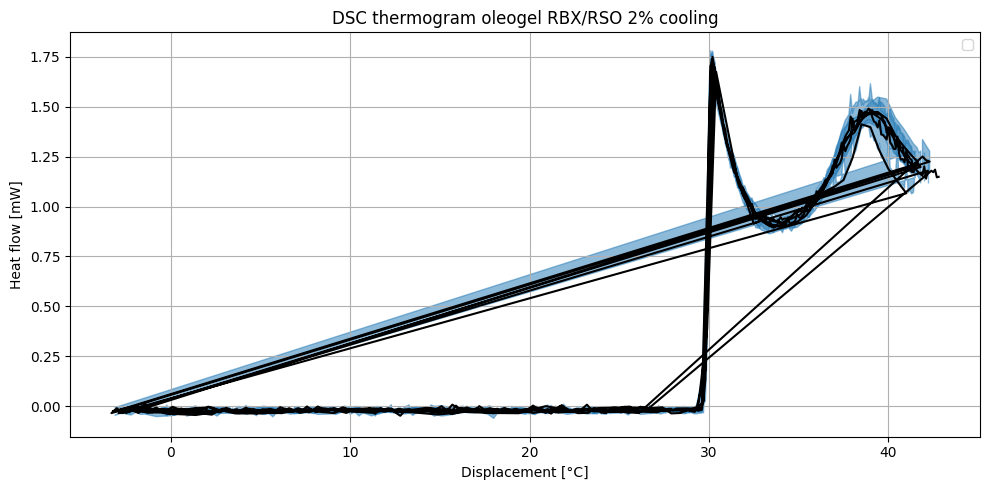

In [277]:
N = 2
namedir = str(N)+"perc/csv"
PlotterSingle(namedir, N, cooling_or_heating, **kwargs)



0.07708999999999999
0.03972
0.040305
-0.00465
0.01613
0.027979999999999998
0.12188666666666666
0.132962
0.10919000000000001
0.10733000000000001
0.09953000000000001
0.12533999999999998
0.136758
0.09749666666666668
0.132822
0.137342
0.12540333333333334
0.13325599999999999
0.10724333333333334
0.138024
0.141218
0.13102
0.142052
0.10030333333333334
0.139274
0.13750800000000002
0.12707666666666664
0.128078
0.10348
0.134596
0.136812
0.13351666666666664
0.139146
0.10440333333333333
0.132498
0.144266
0.12381666666666667
0.139994
0.10162
0.13085399999999997
0.138052
0.11925333333333334
0.138822
0.10681666666666667
0.12673
0.136156
0.12444
0.133666
0.10735666666666666
0.13495
0.13869199999999998
0.12856333333333334
0.14452199999999998
0.10351666666666666
0.139156
0.13717
0.11726666666666667
0.133472
0.10299666666666667
0.142764
0.134892
0.13194666666666668
0.136618
0.10160333333333334
0.137372
0.13920400000000002
0.12188666666666666
0.14434
0.10280666666666667
0.1417
0.133188
0.13568333333333332


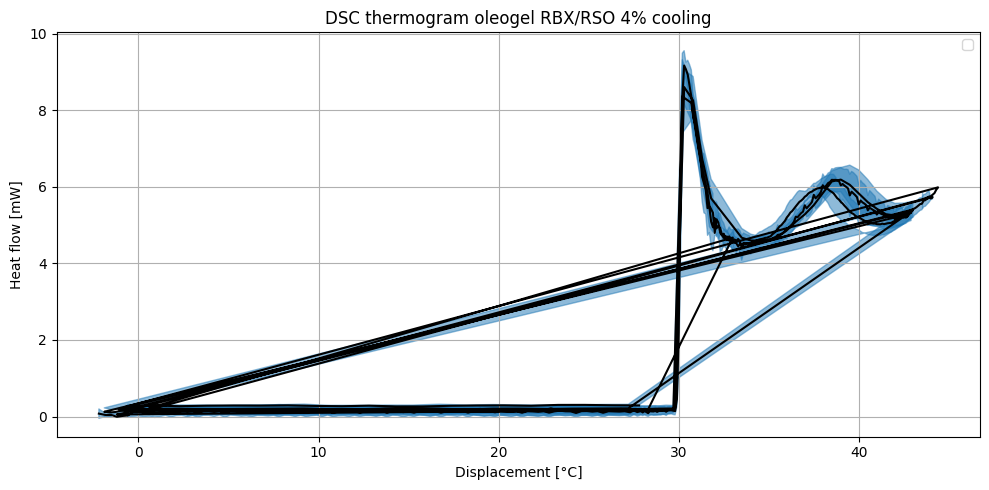

In [278]:
N = 4
namedir = str(N)+"perc/csv"

PlotterSingle(namedir, N, cooling_or_heating, **kwargs)



0.322845
0.33077999999999996
0.34214666666666665
0.34506666666666663
0.3527425
0.35644750000000003
0.33084
0.36155875
0.331045
0.35567000000000004
0.3489675
0.31759
0.3481075
0.336545
0.34815
0.34053500000000003
0.326245
0.3461575
0.32001999999999997
0.3461166666666667
0.34062749999999997
0.316785
0.33999999999999997
0.32498000000000005
0.34818
0.3410275
0.317435
0.33576
0.325455
0.34376000000000007
0.3436975
0.328125
0.34626749999999995
0.33682
0.34936666666666666
0.3397175
0.32977999999999996
0.3492875
0.321465
0.3576333333333333
0.3455575
0.321065
0.34520000000000006
0.3277
0.34992666666666666
0.35118
0.33135000000000003
0.34868
0.33743
0.36619
0.3574125
0.33035
0.3531125
0.32986000000000004
0.34951
0.3444
0.327155
0.3473925
0.320485
0.34667333333333333
0.3513825
0.323395
0.35049749999999996
0.32754
0.3466
0.34884249999999994
0.33308499999999996
0.345535
0.343245
0.34446
0.3479125
0.32271
0.35045000000000004
0.316875
0.35340666666666665
0.3486325
0.32808499999999996
0.3469925
0.3243

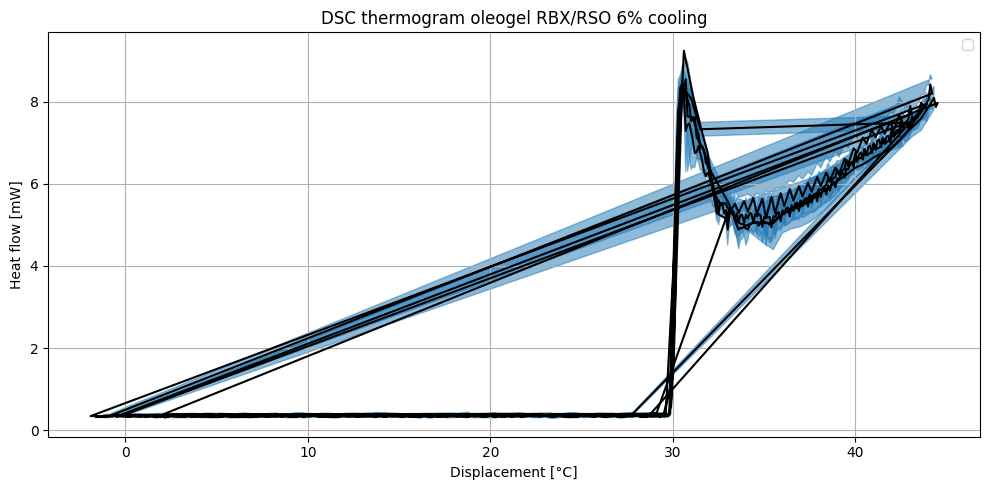

In [279]:
N = 6
namedir = str(N)+"perc/csv"

PlotterSingle(namedir, N, cooling_or_heating, **kwargs)


0.43011666666666665
0.427546
0.42289333333333334
0.436052
0.425596
0.4334057142857143
0.4350528571428572
0.43494
0.4350066666666666
0.42808999999999997
0.4346833333333333
0.43394600000000005
0.439166
0.44213399999999997
0.437136
0.438804
0.43199
0.428974
0.44048800000000005
0.44041399999999997
0.437026
0.43350600000000006
0.43407
0.43567799999999995
0.43285599999999996
0.435722
0.43715200000000004
0.42798600000000003
0.436892
0.43198
0.439836
0.434312
0.43536400000000003
0.43196199999999996
0.44240599999999997
0.431288
0.43079600000000007
0.43833199999999994
0.43982200000000005
0.44493800000000006
0.4313219999999999
0.43576800000000004
0.4412279999999999
0.440028
0.43209200000000003
0.43383200000000005
0.441664
0.433558
0.4389060000000001
0.43657399999999996
0.43379400000000007
0.435098
0.43601799999999996
0.43574799999999997
0.43639199999999995
0.437588
0.434466
0.44489
0.4368
0.43823
0.43533999999999995
0.445396
0.43238199999999993
0.444784
0.44137000000000004
0.43246399999999996
0.4

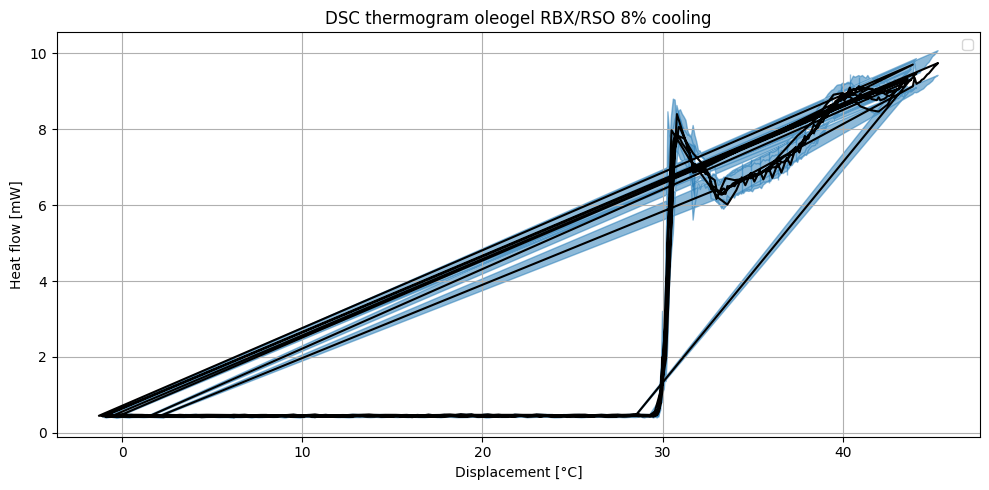

In [280]:
N = 8
namedir = str(N)+"perc/csv"

PlotterSingle(namedir, N, cooling_or_heating, **kwargs)


# Together

In [281]:
displacement = 1

PlotterMultiple(namedir, displacement, cooling_or_heating, **kwargs)
